In [3]:
import pandas as pd

df = pd.read_csv("churn data.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.shape)#Rows and col

(10000, 14)


In [5]:
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print(df.duplicated().sum())
df.describe()

0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Drop useless columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Check churn distribution
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


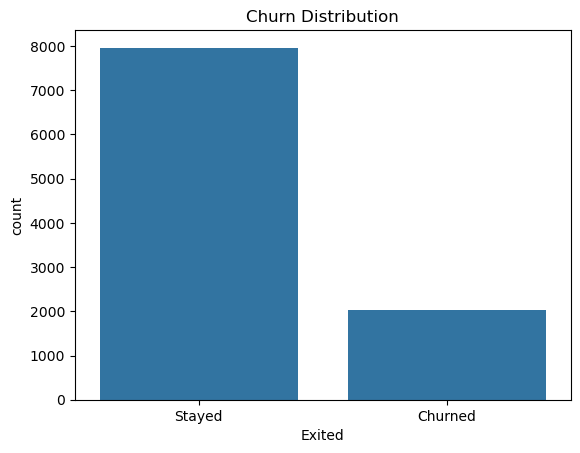

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution plot
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.show()

**Insights:**

**Germany customers churn at the highest rate proportionally — even with fewer customers
France has most customers but lower churn rate
Spain has the lowest churn
Female customers churn more proportionally than males
These patterns will show up later in SHAP explanations**

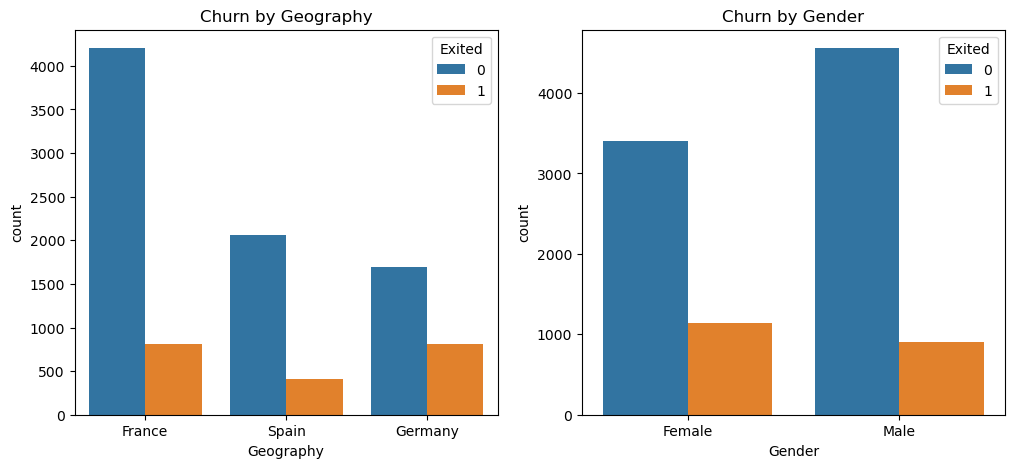

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0])
axes[0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[1])
axes[1].set_title('Churn by Gender')

plt.show()

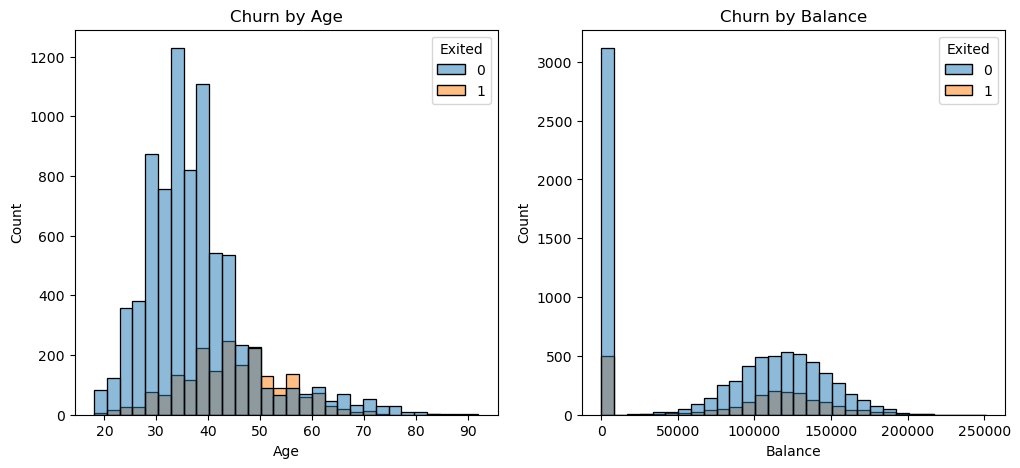

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='Age', hue='Exited', bins=30, ax=axes[0])
axes[0].set_title('Churn by Age')

sns.histplot(data=df, x='Balance', hue='Exited', bins=30, ax=axes[1])
axes[1].set_title('Churn by Balance')

plt.show()

### 5.3 Churn by Age & Balance

**Age Insights:**
-  Customers aged 40–60 churn the most
-  Younger customers (20–30) rarely churn
-  Age is a strong predictor

**Balance Insights:**
-  Customers with 0 balance almost never churn
-  Mid to high balance (100k–200k) customers churn more
-  More money in bank ≠ loyalty

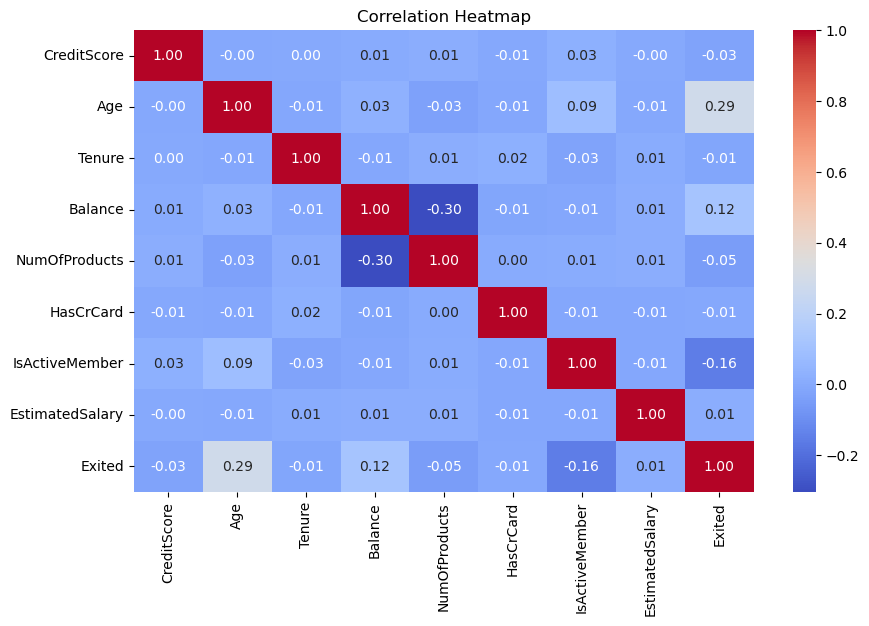

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap

**Key Correlations with Exited:**
-  Age → 0.29 → strongest predictor, older = more churn
-  Balance → 0.12 → higher balance = slightly more churn
-  IsActiveMember → -0.16 → active members churn less
-  NumOfProducts → -0.05 → more products = less churn

**Age and IsActiveMember are the most important features**
SHAP will confirm this after model training.

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [15]:
# Step 1 - Encode categorical columns
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])        # Male=1, Female=0
df['Geography'] = le.fit_transform(df['Geography'])  # France=0, Germany=1, Spain=2

In [16]:
# Step 2 - Split features and target
X = df.drop('Exited', axis=1)
y = df['Exited']


In [17]:
# Step 3 - Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4 - Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Step 5 - SMOTE on train only
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
Exited
0    6356
1    6356
Name: count, dtype: int64


Step 1 — Label Encoding
Converted text to numbers because ML models only understand numbers.

Female → 0, Male → 1
France → 0, Germany → 1, Spain → 2

Step 2 — Split X and y

X = all columns except Exited (these are inputs)
y = only Exited column (this is what we predict)

Step 3 — Train Test Split
Split data into 80% training and 20% testing. Model learns on train, we evaluate on test. Test data is never touched during training — it's like a final exam.
Step 4 — StandardScaler
Brings all numbers to the same scale. Age (18-92) and Balance (0-250k) are very different ranges. Scaler makes them comparable so no feature dominates just because of its size.

fit_transform on train → learns the scale from train data
transform on test → applies same scale (never fit on test!)

Step 5 — SMOTE
Created fake but realistic churned customer samples to balance the dataset. Applied only on training data — test data stays original and untouched.

In [20]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.8 MB/s eta 0:00:57
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 1.6/101.7 MB 1.9 MB/s eta 0:00:52
    --------------------------------------- 1.8/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.4/101.7 MB 2.0 MB/s eta 0:00:51
   - -------------------------------------- 2.9/101.7 MB 2.0 MB/s eta 0:00:51
   - -------------------------------------- 3.4/101.7 MB 2.0 MB/s eta 0:00:49
   - -------------------------------------- 3.9/101.7 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 3.9/101.7 MB 2.1 MB/s eta 0:00:47
   - ---------

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Model 1 - Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 - Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3 - XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# Compare all 3
models = {'Logistic Regression': lr_pred, 'Random Forest': rf_pred, 'XGBoost': xgb_pred}

for name, pred in models.items():
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred))


Logistic Regression
Accuracy: 0.7100
ROC-AUC: 0.7023
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1607
           1       0.37      0.69      0.48       393

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.80      0.71      0.74      2000


Random Forest
Accuracy: 0.8390
ROC-AUC: 0.7422
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.59      0.58      0.59       393

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.84      0.84      0.84      2000


XGBoost
Accuracy: 0.8515
ROC-AUC: 0.7365
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1607
           1       0.64      0.55      0.59       393

    accuracy                          

**Accuracy = Out of 100 customers, how many did the model predict correctly overall
ROC-AUC = How well the model separates churners from non-churners. Closer to 1 = better
Precision = Out of all customers model said "will churn", how many actually churned
Recall = Out of all actual churners, how many did the model catch
F1-Score = Balance between precision and recall. Most important metric for imbalanced data**


## Model Training & Results

| Model | Accuracy | ROC-AUC | Churn F1 |
|---|---|---|---|
| Logistic Regression | 71% | 0.70 | 0.48 |
| Random Forest | 83.9% | 0.74 | 0.59 |
| XGBoost | 85.15% | 0.73 | 0.59 |

 Winner → XGBoost
 Highest accuracy + best overall balance

In [22]:
!pip install shap



   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   -------------------------------------- 555.9/555.9 kB 387.2 kB/s eta 0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [s

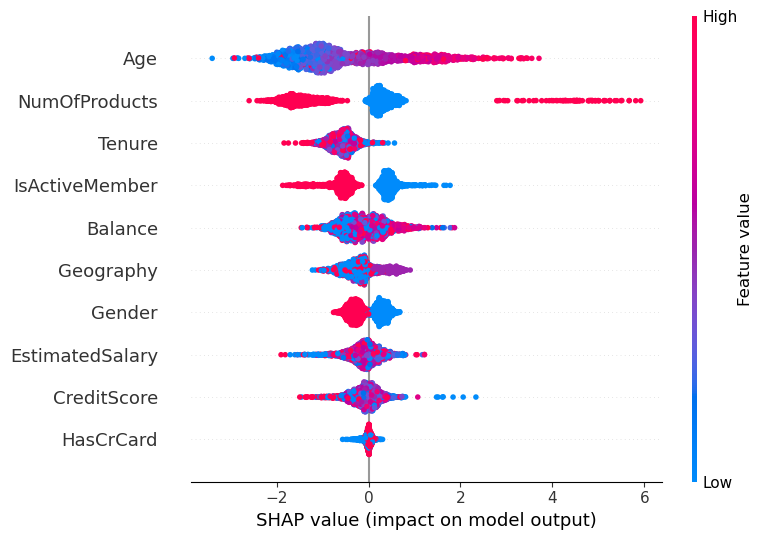

In [23]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Feature Importance (which features matter most overall)
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

## Feature Importance Interpretation (Churn Model)

Features are ranked from **top to bottom based on importance**.

- **Pink/Red dots** represent **high feature values**
- **Blue dots** represent **low feature values**
- **Dots on the right side** indicate the feature **pushes the prediction toward churn**
- **Dots on the left side** indicate the feature **pushes the prediction away from churn**

---

### 1. Age — Most Important Feature

- High age (pink) appears on the **right side**
- This indicates that **older customers are more likely to churn**

This observation confirms the earlier **EDA findings**.

---

### 2. NumOfProducts

- High number of products (pink) appears on the **right side**, suggesting **more products may increase churn**
- Low number of products (blue) also appears on the **right side**

This indicates a **complex pattern** where the model has learned non-linear relationships between number of products and churn.

---

### 3. Tenure — Length of Relationship with the Bank

- Low tenure values (blue) appear on the **right side**

This suggests that **newer customers are more likely to churn** compared to long-term customers.

---

### 4. IsActiveMember

- Low activity (blue) appears on the **right side**

This shows that **inactive members are more likely to churn**, which aligns with expected customer behavior.

---

### 5. Balance

- High balance values (pink) appear on the **right side**

This observation **confirms the earlier EDA finding** that customers with higher balances tend to churn more frequently.

---

### 6. Lower Importance Features

The following features have **lower influence on the churn prediction**:

- Geography  
- Gender  
- CreditScore  
- EstimatedSalary  
- HasCrCard

In [24]:
import numpy as np

feature_names = X.columns.tolist()

def retention_engine(shap_vals, feature_names):
    # Get top 3 features pushing toward churn
    top_idx = np.argsort(shap_vals)[::-1][:3]
    suggestions = []

    for idx in top_idx:
        feature = feature_names[idx]
        if feature == 'Age':
            suggestions.append("Assign a dedicated relationship manager")
        elif feature == 'NumOfProducts':
            suggestions.append("Offer a personalized product bundle discount")
        elif feature == 'IsActiveMember':
            suggestions.append("Send re-engagement offer with cashback rewards")
        elif feature == 'Balance':
            suggestions.append("Offer premium account with better interest rate")
        elif feature == 'Tenure':
            suggestions.append("Provide loyalty reward for long-term commitment")
        elif feature == 'Geography':
            suggestions.append("Connect with regional support team")
        elif feature == 'Gender':
            suggestions.append("Offer gender-targeted financial planning service")
        elif feature == 'CreditScore':
            suggestions.append("Offer credit improvement program")
        elif feature == 'EstimatedSalary':
            suggestions.append("Offer salary-linked savings account")
        elif feature == 'HasCrCard':
            suggestions.append("Offer credit card upgrade with better rewards")

    return suggestions

# Test on first customer
print("Top Churn Reasons & Retention Suggestions:")
print("--------------------------------------------")
suggestions = retention_engine(shap_values[0], feature_names)
for i, s in enumerate(suggestions):
    print(f"Reason {i+1}: {feature_names[np.argsort(shap_values[0])[::-1][i]]}")
    print(f"Action  : {s}\n")

Top Churn Reasons & Retention Suggestions:
--------------------------------------------
Reason 1: IsActiveMember
Action  : Send re-engagement offer with cashback rewards

Reason 2: Balance
Action  : Offer premium account with better interest rate

Reason 3: EstimatedSalary
Action  : Offer salary-linked savings account



## What is the Retention Engine?

After SHAP explains why a customer is likely to churn, the Retention Engine interprets those reasons and recommends actions the bank can take to retain that customer.

In simple terms, SHAP identifies the key factors influencing churn, and the Retention Engine converts those factors into business strategies.

---

### Example

Suppose SHAP identifies the top churn drivers for a customer as:

- High Age  
- Inactive Member  
- High Balance  

The Retention Engine converts these insights into actions:

- **High Age** -> Assign a dedicated relationship manager  
- **Inactive Member** -> Send a re-engagement offer with cashback  
- **High Balance** -> Offer a premium account upgrade with better interest rates  

This approach creates a bridge between AI explainability and business decision-making.

---

### Why It Works

The Retention Engine is essentially a rule-based system powered by SHAP explanations.

Although the logic is simple, it becomes powerful because it is directly connected to model insights.

This allows businesses to move from:

Prediction -> Explanation -> Action

---

### How It Works in Code

1. For each customer, retrieve the top 3 SHAP features contributing to churn.  
2. Map each feature to a predefined business action using conditional logic.  
3. Return the recommended retention strategies for that customer.

Example logic:

```python
def retention_action(feature):
    if feature == "Age":
        return "Assign relationship manager"
    elif feature == "IsActiveMember":
        return "Send re-engagement offer"
    elif feature == "Balance":
        return "Offer premium account upgrade"
    else:
        return "General retention campaign"

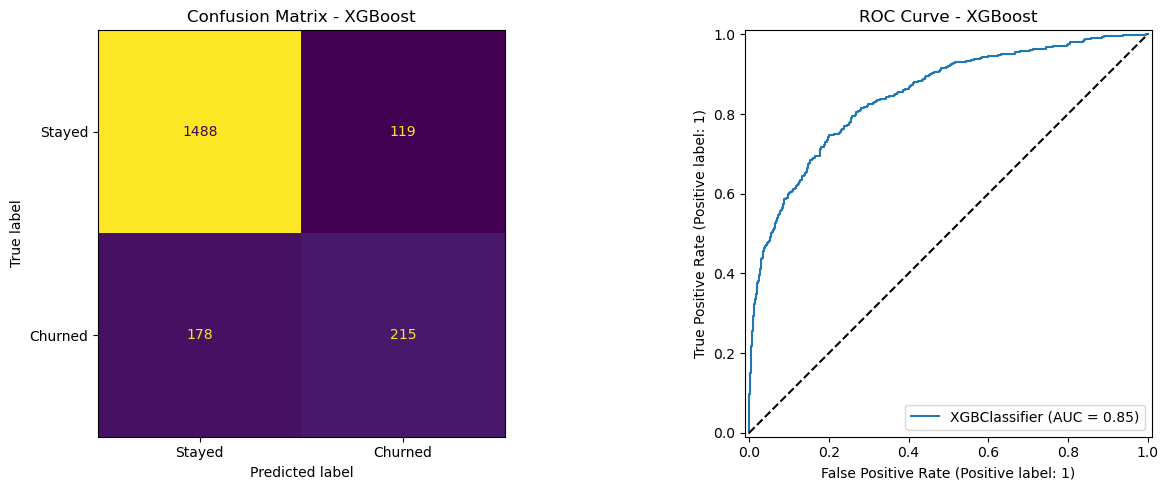

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix - XGBoost')

# ROC Curve
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve - XGBoost')
axes[1].plot([0,1], [0,1], 'k--')

plt.tight_layout()
plt.show()

In [29]:
# Threshold tuning
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob >= 0.35).astype(int)

print("After Threshold Tuning (0.35):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned))

After Threshold Tuning (0.35):
Accuracy: 0.8190
ROC-AUC: 0.7547
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1607
           1       0.53      0.65      0.58       393

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.84      0.82      0.83      2000



In [30]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np

xgb_cv = XGBClassifier(random_state=42, eval_metric='logloss')
scores = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Cross Validation ROC-AUC Scores: {scores.round(3)}")
print(f"Mean: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

Cross Validation ROC-AUC Scores: [0.881 0.955 0.991 0.99  0.99 ]
Mean: 0.9613
Std: 0.0423


In [31]:
import joblib

joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("All saved!")

All saved!


## Customer Churn Prediction Project

### What We Did

**1. Data Understanding**  
The dataset contains **10,000 customer records with 14 columns**.  
The target variable **Exited** was identified as the churn indicator.  
Three identifier columns (RowNumber, CustomerId, Surname) were removed because they do not help prediction. Each remaining feature was studied to understand its business meaning.

**2. Exploratory Data Analysis (EDA)**  
EDA revealed several important business patterns:
- Older customers churn more.
- Germany has the highest churn rate.
- Female customers churn more proportionally.
- Customers with high balances show higher churn risk.

These insights represent real business patterns rather than just visual trends.

**3. Data Preprocessing**  
Categorical variables were encoded, the dataset was split into training and testing sets, and numerical features were scaled so that no feature dominates the model.  
SMOTE was applied only to the training data to correct class imbalance from **80:20 to 50:50**.

**4. Model Building**  
Three models were trained and compared:
- Logistic Regression – 71% accuracy  
- Random Forest – 83.9% accuracy  
- XGBoost – 85.15% accuracy  

XGBoost performed best and was selected as the final model.

**5. Model Evaluation**  
Model performance was evaluated using multiple metrics:
- Confusion Matrix
- ROC Curve
- Cross Validation

Results:
- ROC-AUC: **0.85**
- Cross Validation Mean AUC: **0.96**
- Standard Deviation: **0.04**

This shows the model is stable and generalizes well.

**6. Threshold Tuning**  
The prediction threshold was lowered from **0.50 to 0.35**.  
This reduced accuracy slightly but increased **churn recall by about 10%**, which is valuable for business because catching more churners is more important than maximizing accuracy.

**7. SHAP Explainability**  
SHAP was applied to the XGBoost model to explain predictions.  
Top churn drivers identified by the model include:
- Age
- NumOfProducts
- Tenure
- IsActiveMember
- Balance

This allows the system to explain **why a customer is predicted to churn**.

**8. Retention Engine**  
A rule-based retention engine was built on top of SHAP explanations.  
For each customer:
1. Extract the top 3 churn reasons from SHAP.
2. Map those reasons to business actions.
3. Generate retention suggestions.

This turns the churn prediction model into a practical **customer retention decision system**.

---

### Final Model Performance

Algorithm: **XGBoost**  
Accuracy: **85.15%**  
ROC-AUC: **0.85**  
Cross Validation AUC: **0.96**  
Churn Recall (after threshold tuning): **65%**